   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

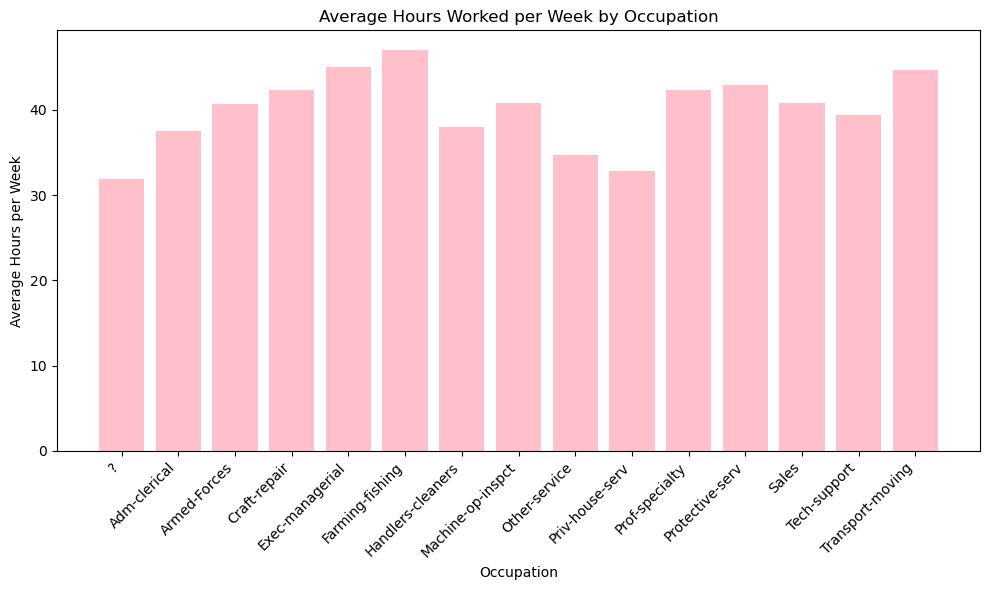

In [16]:
#task 1
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("adult.csv")
print(data.head())
data = data[data["occupation"] != "-"]

 #occ is categorical and hrs per week numerical
avg_hours = data.groupby("occupation")["hours.per.week"].mean()


plt.figure(figsize=(10, 6))
plt.bar(avg_hours.index, avg_hours.values, color="pink")

plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours Worked per Week by Occupation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

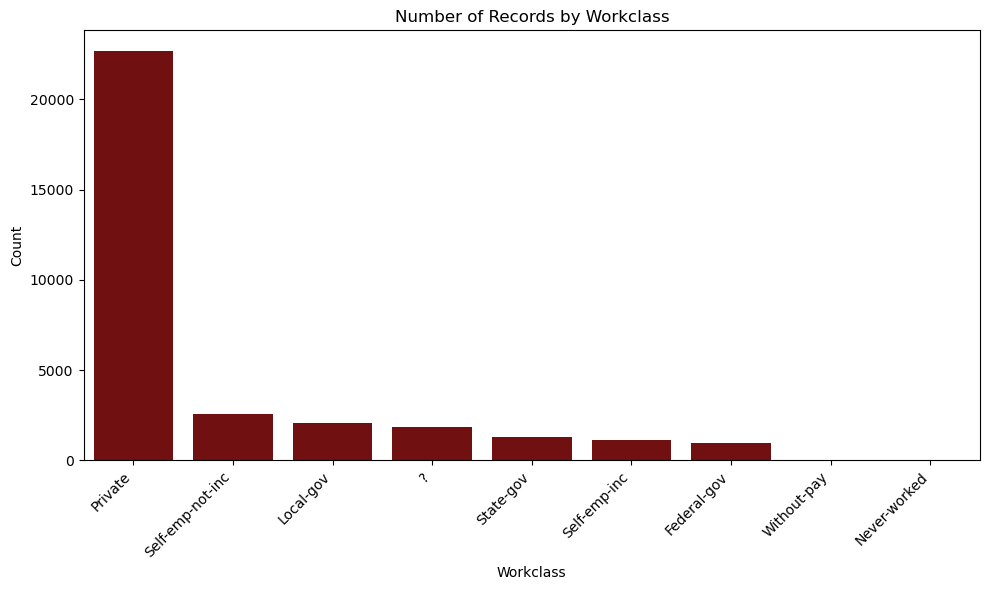

In [17]:
#task 2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("adult.csv")

# Create count plot
plt.figure(figsize=(10, 6))
sns.countplot(x="workclass", data=data, order=data["workclass"].value_counts().index, color="maroon")

# Labels and title
plt.xlabel("Workclass")
plt.ylabel("Count")
plt.title("Number of Records by Workclass")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

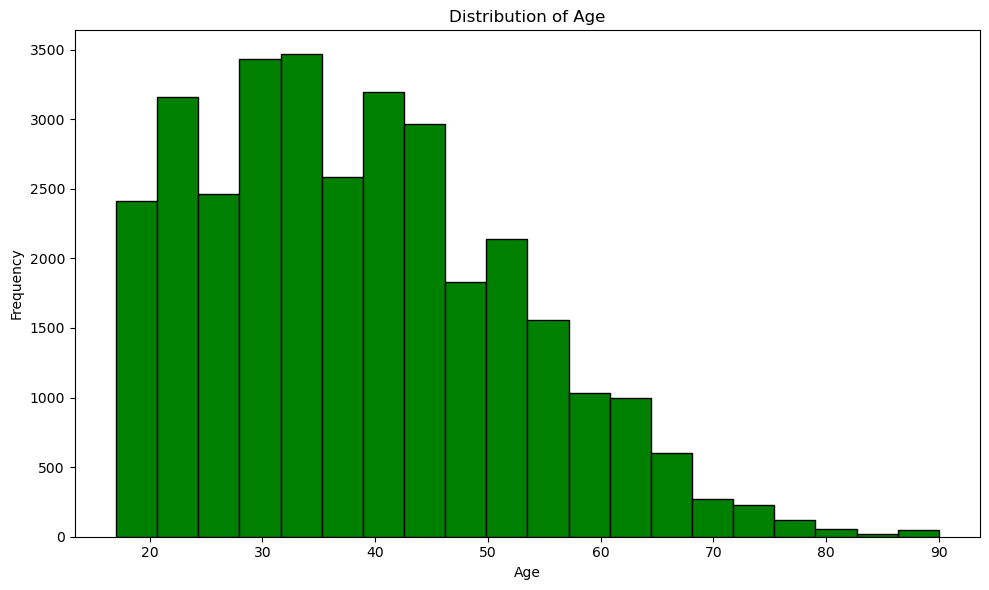

In [12]:
#task 3
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("adult.csv")

#histogram
plt.figure(figsize=(10, 6))
plt.hist(data["age"], bins=20, color="green", edgecolor="black")

# Labels
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")
plt.tight_layout()

plt.show()
#right skewwed

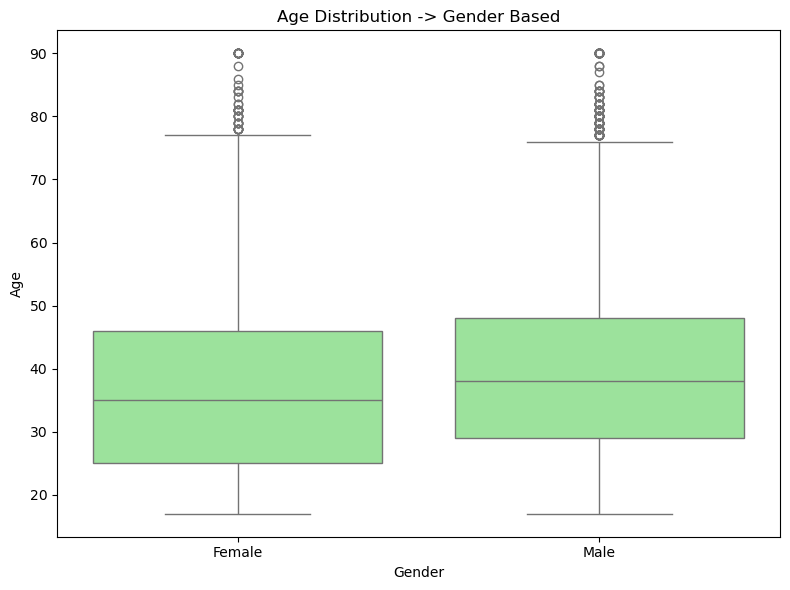

In [22]:
#task 4
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("adult.csv")

plt.figure(figsize=(8, 6))
sns.boxplot(x="sex", y="age", data=data, color="lightgreen")

# Labels
plt.xlabel("Gender")
plt.ylabel("Age")
plt.title("Age Distribution -> Gender Based")
plt.tight_layout()

plt.show()

In [20]:
#task 5
import pandas as pd


data = pd.read_csv("adult.csv")

#IQR bounds
Q1 = data['age'].quantile(0.25)
Q3 = data['age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

#outliers
outliers = data[(data['age'] < lower) | (data['age'] > upper)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower)
print("Upper bound:", upper)
print("Number of outliers:", len(outliers))

#the box plot tells us that outlier beyound the upper whisker in task 4 , in task 5 iqr method identifies having the upper bound 78 so box plot is consistent with iqr calculation.

Q1: 28.0
Q3: 48.0
IQR: 20.0
Lower bound: -2.0
Upper bound: 78.0
Number of outliers: 143


In [6]:
from scipy import stats
data["zscore"] = stats.zscore(data["age"])
outliers_z = data[data["zscore"].abs() > 3]
print("no of outliers :")
print(len(outliers_z))

no of outliers :
121


z-score method finds 121 outliers . No , they are not same as iqr gives more outliers bcz age col is right skewwed.


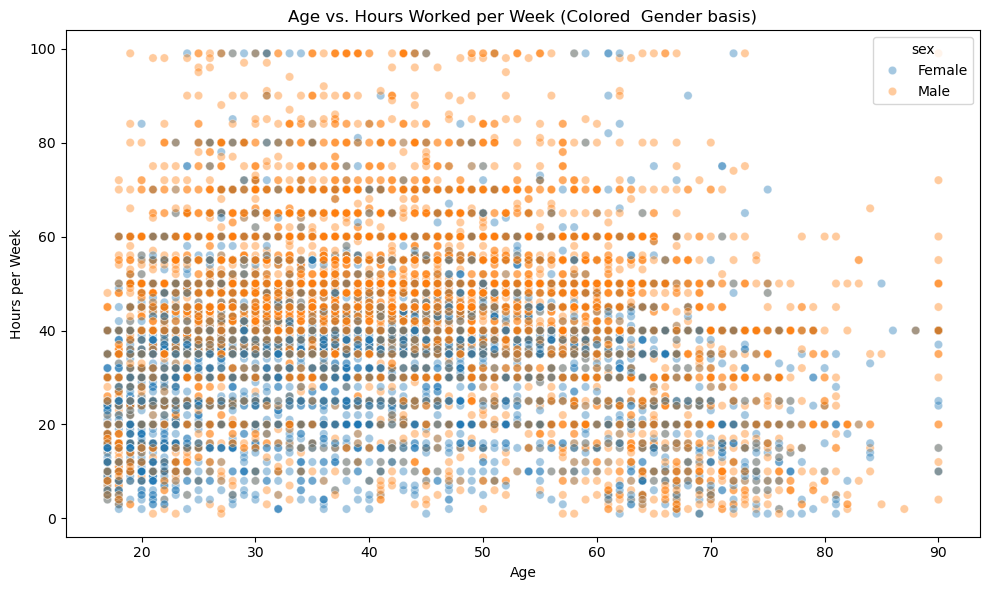

In [3]:
#task 7
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


data = pd.read_csv("adult.csv")

plt.figure(figsize=(10, 6))
sns.scatterplot(x="age", y="hours.per.week", hue="sex", data=data, alpha=0.4)

# Labels and title
plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Age vs. Hours Worked per Week (Colored  Gender basis)")
plt.tight_layout()

plt.show()

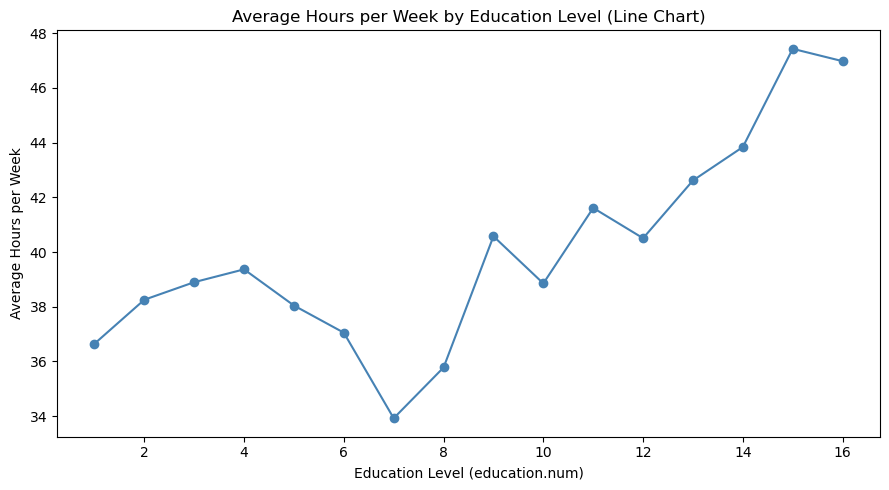

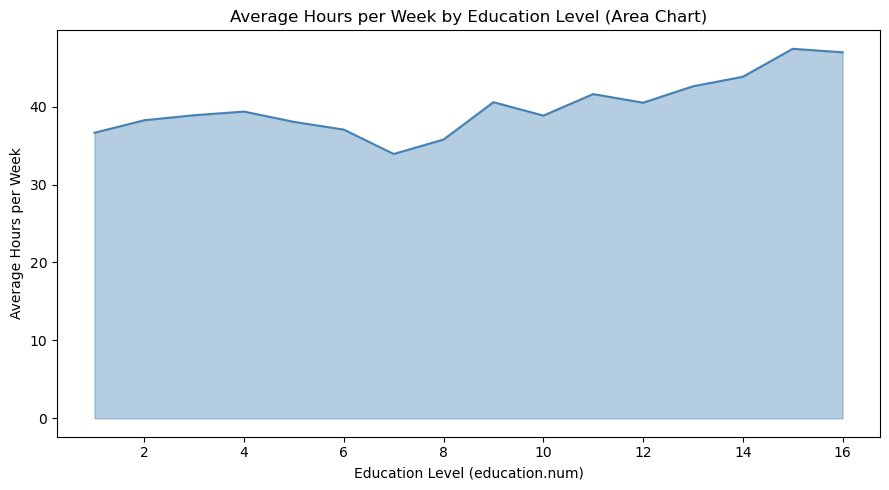

In [25]:
#task 8
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("adult.csv")

avg_hours = data.groupby("education.num")["hours.per.week"].mean().sort_index()

#Line chart
plt.figure(figsize=(9, 5))
plt.plot(avg_hours.index, avg_hours.values, marker="o", color="steelblue")
plt.xlabel("Education Level (education.num)")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours per Week by Education Level (Line Chart)")
plt.tight_layout()
plt.show()

#Area chart
plt.figure(figsize=(9, 5))
plt.fill_between(avg_hours.index, avg_hours.values, color="steelblue", alpha=0.4)
plt.plot(avg_hours.index, avg_hours.values, color="steelblue")
plt.xlabel("Education Level (education.num)")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours per Week by Education Level (Area Chart)")
plt.tight_layout()
plt.show()

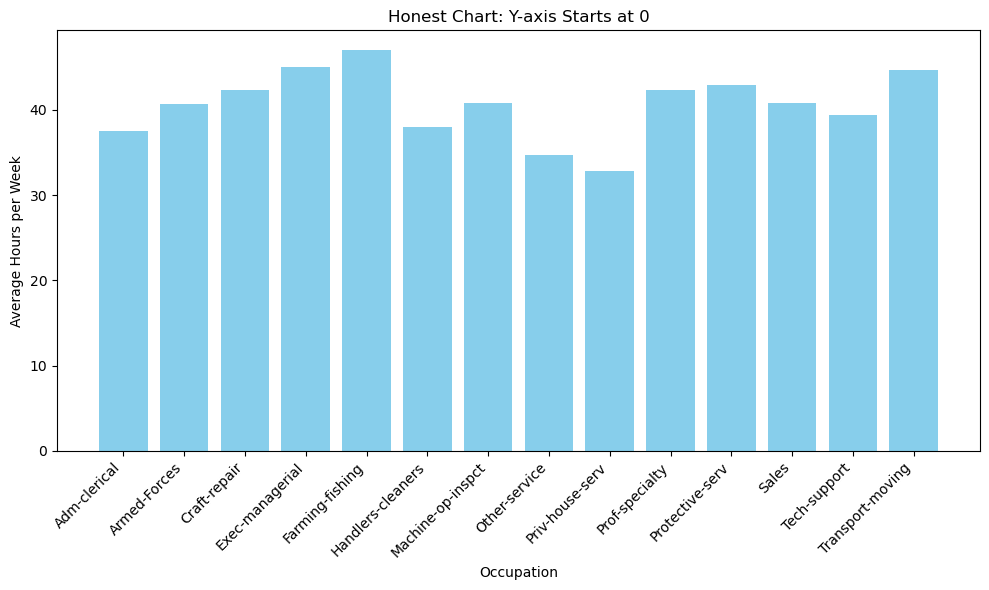

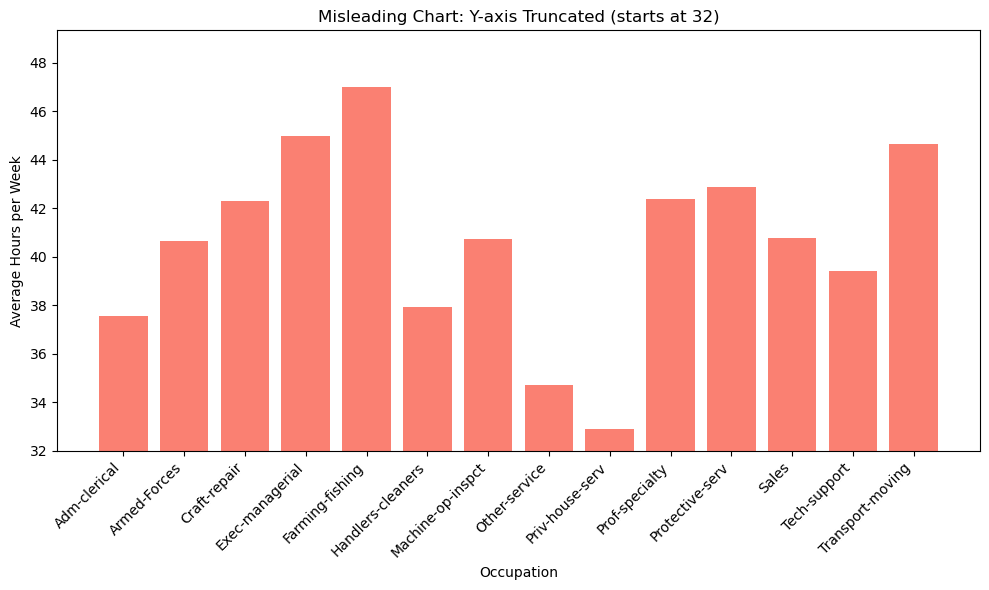

In [27]:
#task 9
import pandas as pd
import matplotlib.pyplot as plt


data = pd.read_csv("adult.csv")
data = data[data["occupation"] != "?"]


avg_hours = data.groupby("occupation")["hours.per.week"].mean()

# --- Version 1: Honest chart (y-axis starts at 0) ---
plt.figure(figsize=(10, 6))
plt.bar(avg_hours.index, avg_hours.values, color="skyblue")
plt.ylim(bottom=0)
plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Honest Chart: Y-axis Starts at 0")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Version 2: Misleading chart (truncated y-axis) ---
plt.figure(figsize=(10, 6))
plt.bar(avg_hours.index, avg_hours.values, color="salmon")
plt.ylim(bottom=32)   # truncated axis, close to the minimum value
plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Misleading Chart: Y-axis Truncated (starts at 32)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

the 